In [1]:
# Basic libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pykalman import KalmanFilter
from itertools import combinations
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import pickle
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

In [2]:
# Scripts 
from src.cointegration import *
from src.kalman import *
from src.pairs import *
from src.trading_signal import *
from src.backtest import *
from src.plots import *
from src.utils import *
from src.refined_trading_signal import *

In [3]:
# Load in data from previous notebook
df1_is = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df1_is",
                     index_col=0, parse_dates=True)
df1_oos = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df1_oos",
                      index_col=0, parse_dates=True)

df2_is = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df2_is",
                     index_col=0, parse_dates=True)
df2_oos = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df2_oos",
                      index_col=0, parse_dates=True)

static_results_df_is = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/static_hedge_ratio_is")
dynamic_results_df_is = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dynamic_hedge_ratio_is")

static_results_df_oos = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/static_hedge_ratio_oos")
dynamic_results_df_oos = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dynamic_hedge_ratio_oos")


In [4]:
# Load dictionaries from previous notebook
# In-Sample
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/static_spreads_is.pkl", "rb") as f:
    static_spreads_is = pickle.load(f)
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/static_models_is.pkl", "rb") as f:
    static_models_is = pickle.load(f)

with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/dynamic_spreads_is.pkl", "rb") as f:
    dynamic_spreads_is = pickle.load(f)
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/dynamic_details_is.pkl", "rb") as f:
    dynamic_details_is = pickle.load(f)

# Out-Of-Sample
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/static_spreads_oos.pkl", "rb") as f:
    static_spreads_oos = pickle.load(f)
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/static_models_oos.pkl", "rb") as f:
    static_models_oos = pickle.load(f)

with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/dynamic_spreads_oos.pkl", "rb") as f:
    dynamic_spreads_oos = pickle.load(f)
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/dynamic_details_oos.pkl", "rb") as f:
    dynamic_details_oos = pickle.load(f)


# Load pairs
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/pairs_is.pkl", "rb") as f:
    pairs_is = pickle.load(f)
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/pairs_oos.pkl", "rb") as f:
    pairs_oss = pickle.load(f)

In [5]:
# Load risk-free rate to calculate sharpe ratio
rf_is = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/rf_is",
                     index_col=0, parse_dates=True) 
rf_oos = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/rf_oos",
                     index_col=0, parse_dates=True)

Original trading strategy:

Mathematically, we can express it in a mapping:
$$
\text{Position}(z) =
\begin{cases}
-1 & \text{if } z > 2 \\
+1 & \text{if } z < -2 \\
\text{hold previous position} & \text{otherwise}
\end{cases}
$$

# Refining trading signals to improve returns

The refined strategy extends the original fixed-threshold z-score approach by replacing static entry bands with rolling, adaptive z-score bands. Rather than applying the same entry thresholds throughout the full sample period, the strategy identifies attractive entry points based on whether the spread is extreme relative to its recent historical behaviour. This allows the model to adjust to changing volatility regimes and reduces the reliance on fixed sensitivity parameters.<br>

In addition, a drawdown-based risk management overlay is introduced. This indicator monitors the performance of active positions and is used to adjust exposure when downside risk increases. Instead of immediately closing positions once losses occur, the strategy can reduce position size during adverse movements, while still allowing scope to increase exposure when large spread deviations create attractive mean-reversion opportunities. This creates a more flexible framework in which rolling z-score bands determine trade attractiveness, while the drawdown overlay manages active risk exposure (*example is with the in-sample pair 700-1347 HK Equity [mid 2015-2016]*).

![image](/Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/trading_signal_plots_is/entry_1.5_exit_0.0_700_HK_Equity_vs_1347_HK_Equity_R0.5.png)

This creates a two-layer framework in which the rolling z-score bands determine trade entry and exit conditions, while the drawdown overlay controls downside risk.<br>

Therefore, the **rolling bands** will **determine the direction of the pairs spread** and the *drawdown* will **determine the position size**.

To make the test relatively fair, we keep the rolling windows relatively small (60 days) becuase we want to have a comparison between the in-sample and out-of-sample. Also, we want to keep the rolling windows relatively small as having too large of windows may create too much noise in the signals, creating false/inaccurate entry/exit positions, to out of date information.<br>

The band window is set larger (120 days) than the z-score window because the bands are intended to capture the recent distribution of extreme spread movements. A longer window provides a more stable estimate of the 90th and 10th percentile thresholds, reducing the risk that the bands adjust too quickly to short-term noise.<br>

In summary:
- z-window: measures the current spread relative to recent mean and volatility.
- Band window: measures what has recently counted as an unusually high or low z-score.
- Larger band window: makes the extreme thresholds more stable.

## In-sample 

In [6]:
dynamic_details_is

{('700 HK Equity vs 1347 HK Equity',
  0.5):                    y         x   alpha_t    beta_t  spread_t  obs_cov
 Date                                                                 
 2015-01-02  4.597148  2.175547  0.737549  1.604573  0.368775      0.5
 2015-01-05  4.603339  2.162173  0.772797  1.675708  0.207371      0.5
 2015-01-06  4.659024  2.188632  0.783063  1.703784  0.147003      0.5
 2015-01-07  4.695038  2.178495  0.791309  1.722627  0.150994      0.5
 2015-01-08  4.718079  2.183576  0.796288  1.735401  0.132412      0.5
 ...              ...       ...       ...       ...       ...      ...
 2020-12-24  6.207606  3.808062  4.174089  0.568151 -0.130036      0.5
 2020-12-28  6.138742  3.793667  4.176448  0.564741 -0.180147      0.5
 2020-12-29  6.160659  3.816833  4.178816  0.561604 -0.161706      0.5
 2020-12-30  6.213882  3.820105  4.180271  0.559606 -0.104144      0.5
 2020-12-31  6.221892  3.775653  4.180828  0.558433 -0.067384      0.5
 
 [1478 rows x 6 columns],
 ('70

In [7]:
is_refined_results_trial = generate_refined_kalman_signals(
    dynamic_details= dynamic_details_is,
    z_window = 60, 
    band_window= 120,
    reduce_dd = -0.06, 
    close_dd = -1.00
    )

In [8]:
is_refined_results_trial.head()


,y,x,alpha_t,beta_t,spread_t,obs_cov,rolling_mean,rolling_std,zscore,upper_band,...,risk_state,pair,z_window,band_window,upper_quantile,lower_quantile,exit_z,reduce_dd,close_dd,reduced_exposure
Date,,,,,,,,,,,,,,,,,,,,,
2015-09-23,4.748205,1.916628,2.373520,1.233308,0.010892,0.5,0.145873,0.082383,-1.638454,1.725495,...,flat,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.06,-1.0,0.5
2015-09-24,4.746670,1.917951,2.373746,1.233315,0.007487,0.5,0.145034,0.083544,-1.646411,1.725495,...,normal,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.06,-1.0,0.5
2015-09-25,4.748967,1.912649,2.374246,1.233316,0.015822,0.5,0.142512,0.085134,-1.488131,1.725495,...,normal,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.06,-1.0,0.5
2015-09-29,4.720319,1.888432,2.374928,1.233233,0.016514,0.5,0.138791,0.085688,-1.427005,1.725495,...,normal,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.06,-1.0,0.5
2015-09-30,4.735900,1.947766,2.374345,1.232878,-0.039802,0.5,0.133752,0.087164,-1.991113,1.725495,...,normal,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.06,-1.0,0.5


**Actual parameters used:**

In [9]:
is_refined_results = generate_refined_kalman_signals(
    dynamic_details= dynamic_details_is,
    z_window = 60, 
    band_window= 120,
    reduce_dd = -0.15, 
    close_dd = -1.00
    )

In [10]:
is_refined_results.head()

,y,x,alpha_t,beta_t,spread_t,obs_cov,rolling_mean,rolling_std,zscore,upper_band,...,risk_state,pair,z_window,band_window,upper_quantile,lower_quantile,exit_z,reduce_dd,close_dd,reduced_exposure
Date,,,,,,,,,,,,,,,,,,,,,
2015-09-23,4.748205,1.916628,2.373520,1.233308,0.010892,0.5,0.145873,0.082383,-1.638454,1.725495,...,flat,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.15,-1.0,0.5
2015-09-24,4.746670,1.917951,2.373746,1.233315,0.007487,0.5,0.145034,0.083544,-1.646411,1.725495,...,normal,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.15,-1.0,0.5
2015-09-25,4.748967,1.912649,2.374246,1.233316,0.015822,0.5,0.142512,0.085134,-1.488131,1.725495,...,normal,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.15,-1.0,0.5
2015-09-29,4.720319,1.888432,2.374928,1.233233,0.016514,0.5,0.138791,0.085688,-1.427005,1.725495,...,normal,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.15,-1.0,0.5
2015-09-30,4.735900,1.947766,2.374345,1.232878,-0.039802,0.5,0.133752,0.087164,-1.991113,1.725495,...,normal,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.15,-1.0,0.5


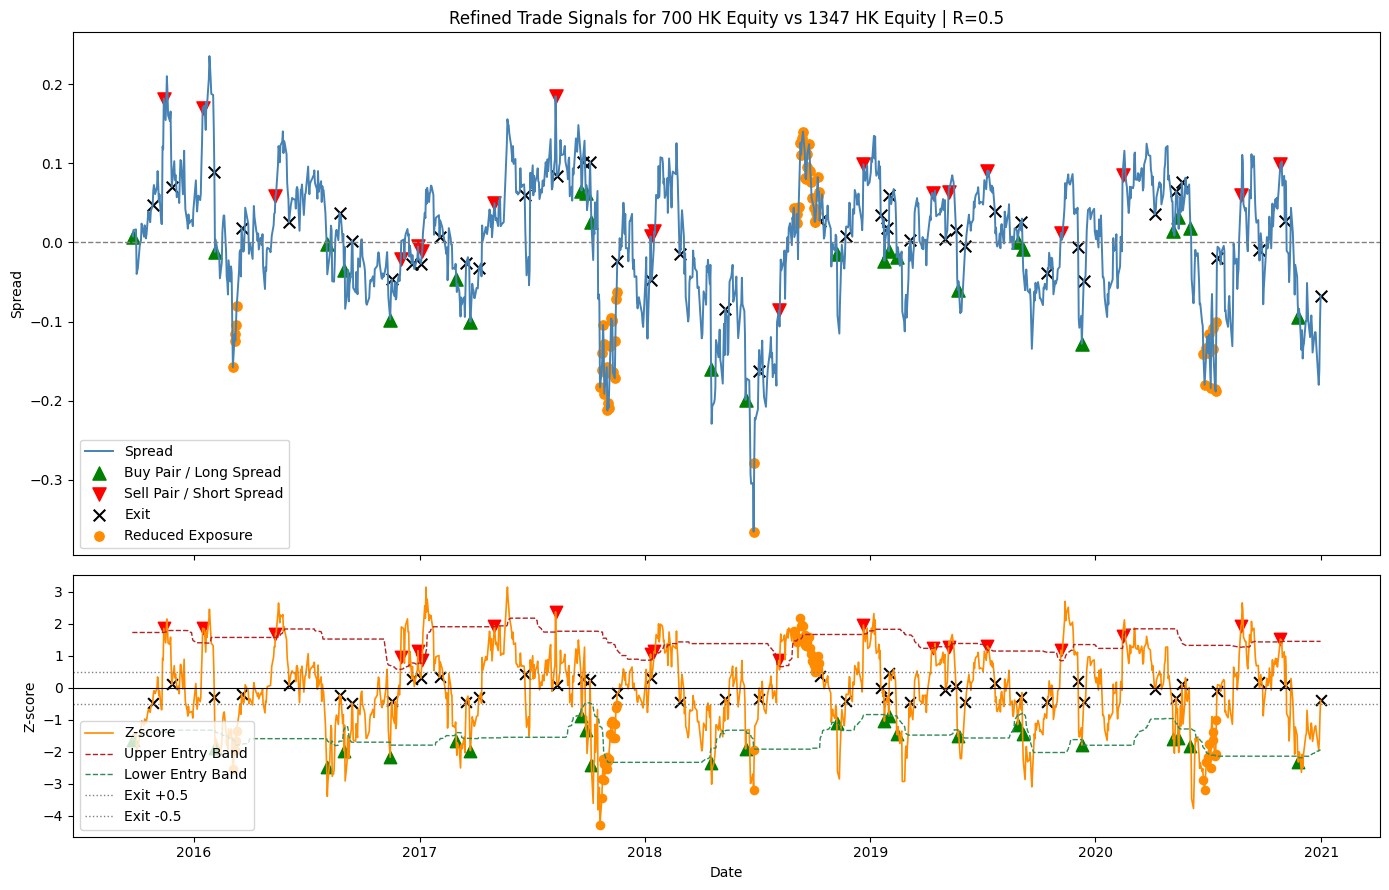

In [11]:
plt.ion()
plot_refined_trade_signals(is_refined_results, "700 HK Equity vs 1347 HK Equity")

In [12]:
save_dir = "/Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/refined_trading_signal_plots_is"
os.makedirs(save_dir, exist_ok=True)

plt.ioff()  

pair_r_combinations = (
    is_refined_results[["pair", "obs_cov"]]
    .drop_duplicates()
    .sort_values(["pair", "obs_cov"])
    .itertuples(index=False, name=None)
)

for pair_name, obs_cov in pair_r_combinations:

    # create the plot
    plot_refined_trade_signals(
        signals_df=is_refined_results,
        pair_name=pair_name,
        obs_cov=obs_cov
    )

    # clean filename
    clean_pair_name = (
        pair_name
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
    )

    filename = f"refined_{clean_pair_name}_R{obs_cov}.png"
    filepath = os.path.join(save_dir, filename)

    # save current figure
    plt.savefig(filepath, dpi=300, bbox_inches="tight")

    plt.close()

print(f"Saved all refined trade signal plots to: {save_dir}")

Saved all refined trade signal plots to: /Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/refined_trading_signal_plots_is


### Performance Metrics

In [13]:
rf_is_fixed = (
    rf_is
    .copy()
    .reset_index()
    .rename(columns={"date": "Date"})
)

rf_is_fixed["Date"] = pd.to_datetime(rf_is_fixed["Date"])

In [14]:
refined_is_performance_metrics = refined_performance_metrics(
    is_refined_results,
    rf=rf_is_fixed
)

refined_is_performance_metrics

,strategy,pair,obs_cov,entry_z,exit_z,z_window,band_window,upper_quantile,lower_quantile,average_pnl,...,annualised_return (%),annualised_volatility (%),sharpe,annualised_sharpe,hit_rate (%),num_trades,max_trade_drawdown,n_obs,n_active_days,active_day_ratio (%)
0,refined_dynamic_bands,1088 HK Equity vs 1171 HK Equity,0.5,NaN,0.5,60,120,0.9,0.1,0.000696,...,16.469804,14.518686,0.071460,1.134387,24.326405,43.50,-0.164794,1299,570,43.879908
1,refined_dynamic_bands,1088 HK Equity vs 1171 HK Equity,1.0,NaN,0.5,60,120,0.9,0.1,0.000611,...,14.330294,14.684511,0.061475,0.975878,25.096228,46.00,-0.170902,1299,579,44.572748
2,refined_dynamic_bands,1088 HK Equity vs 1171 HK Equity,5.0,NaN,0.5,60,120,0.9,0.1,0.000531,...,12.321930,16.025504,0.048436,0.768895,25.789069,47.00,-0.210434,1299,626,48.190916
3,refined_dynamic_bands,1088 HK Equity vs 3993 HK Equity,0.5,NaN,0.5,60,120,0.9,0.1,0.000533,...,12.360622,19.361425,0.040216,0.638415,28.560431,38.50,-0.141276,1299,681,52.424942
4,refined_dynamic_bands,1088 HK Equity vs 3993 HK Equity,1.0,NaN,0.5,60,120,0.9,0.1,0.000409,...,9.241332,19.778407,0.029434,0.467244,29.099307,38.00,-0.165391,1299,693,53.348730
5,refined_dynamic_bands,1088 HK Equity vs 3993 HK Equity,5.0,NaN,0.5,60,120,0.9,0.1,0.000440,...,10.039998,21.565378,0.029328,0.465561,30.023095,37.00,-0.209968,1299,728,56.043110
6,refined_dynamic_bands,1347 HK Equity vs 268 HK Equity,0.5,NaN,0.5,60,120,0.9,0.1,0.000974,...,23.491427,32.510097,0.045519,0.722589,28.637413,48.00,-0.301792,1299,681,52.424942
7,refined_dynamic_bands,1347 HK Equity vs 268 HK Equity,1.0,NaN,0.5,60,120,0.9,0.1,0.000913,...,21.937276,32.717656,0.042238,0.670503,28.098537,46.00,-0.336215,1299,675,51.963048
8,refined_dynamic_bands,1347 HK Equity vs 268 HK Equity,5.0,NaN,0.5,60,120,0.9,0.1,0.000840,...,20.118780,35.145023,0.036061,0.572450,27.328714,45.50,-0.376532,1299,671,51.655119
9,refined_dynamic_bands,1898 HK Equity vs 2386 HK Equity,0.5,NaN,0.5,60,120,0.9,0.1,0.001162,...,28.235082,22.338112,0.079624,1.263987,26.558891,50.50,-0.215760,1299,643,49.499615


## Out-of-sample

In [15]:
dynamic_details_oos

{('700 HK Equity vs 1347 HK Equity',
  0.5):                    y         x   alpha_t    beta_t  spread_t  obs_cov
 Date                                                                 
 2021-01-04  6.236851  3.714742  0.407656  1.514336  0.203828      0.5
 2021-01-05  6.255882  3.763059  0.410816  1.533329  0.075061      0.5
 2021-01-06  6.277917  3.761921  0.412256  1.541719  0.065836      0.5
 2021-01-07  6.229840  3.697691  0.416342  1.548389  0.088034      0.5
 2021-01-08  6.237723  3.695234  0.419249  1.552979  0.079851      0.5
 ...              ...       ...       ...       ...       ...      ...
 2023-01-20  5.946370  3.430271  2.131668  1.094229  0.061202      0.5
 2023-01-26  5.983941  3.495507  2.130222  1.095072  0.025886      0.5
 2023-01-27  6.003897  3.489483  2.127708  1.096605  0.049603      0.5
 2023-01-30  5.934561  3.436661  2.126578  1.097502  0.036242      0.5
 2023-01-31  5.921562  3.399296  2.125496  1.098754  0.061078      0.5
 
 [511 rows x 6 columns],
 ('700

In [16]:
oos_refined_results = generate_refined_kalman_signals(
    dynamic_details= dynamic_details_oos,
    z_window = 60, 
    band_window= 120,
    reduce_dd = -0.06, 
    close_dd = -1.00
    )

In [17]:
oos_refined_results.head()

,y,x,alpha_t,beta_t,spread_t,obs_cov,rolling_mean,rolling_std,zscore,upper_band,...,risk_state,pair,z_window,band_window,upper_quantile,lower_quantile,exit_z,reduce_dd,close_dd,reduced_exposure
Date,,,,,,,,,,,,,,,,,,,,,
2021-09-23,6.027719,3.720766,1.096624,1.317796,0.027886,0.5,-0.075129,0.130947,0.786691,0.977399,...,flat,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.06,-1.0,0.5
2021-09-24,6.021222,3.723160,1.097007,1.317952,0.017268,0.5,-0.074207,0.131406,0.696121,0.977399,...,flat,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.06,-1.0,0.5
2021-09-27,6.030738,3.719554,1.097686,1.318218,0.029867,0.5,-0.074081,0.131504,0.790456,0.977399,...,flat,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.06,-1.0,0.5
2021-09-28,6.041868,3.726753,1.098242,1.318518,0.029836,0.5,-0.073249,0.132008,0.780899,0.977399,...,flat,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.06,-1.0,0.5
2021-09-29,6.031598,3.691526,1.100313,1.318896,0.062546,0.5,-0.072456,0.132688,1.017433,0.977399,...,normal,700 HK Equity vs 1347 HK Equity,60,120,0.9,0.1,0.5,-0.06,-1.0,0.5


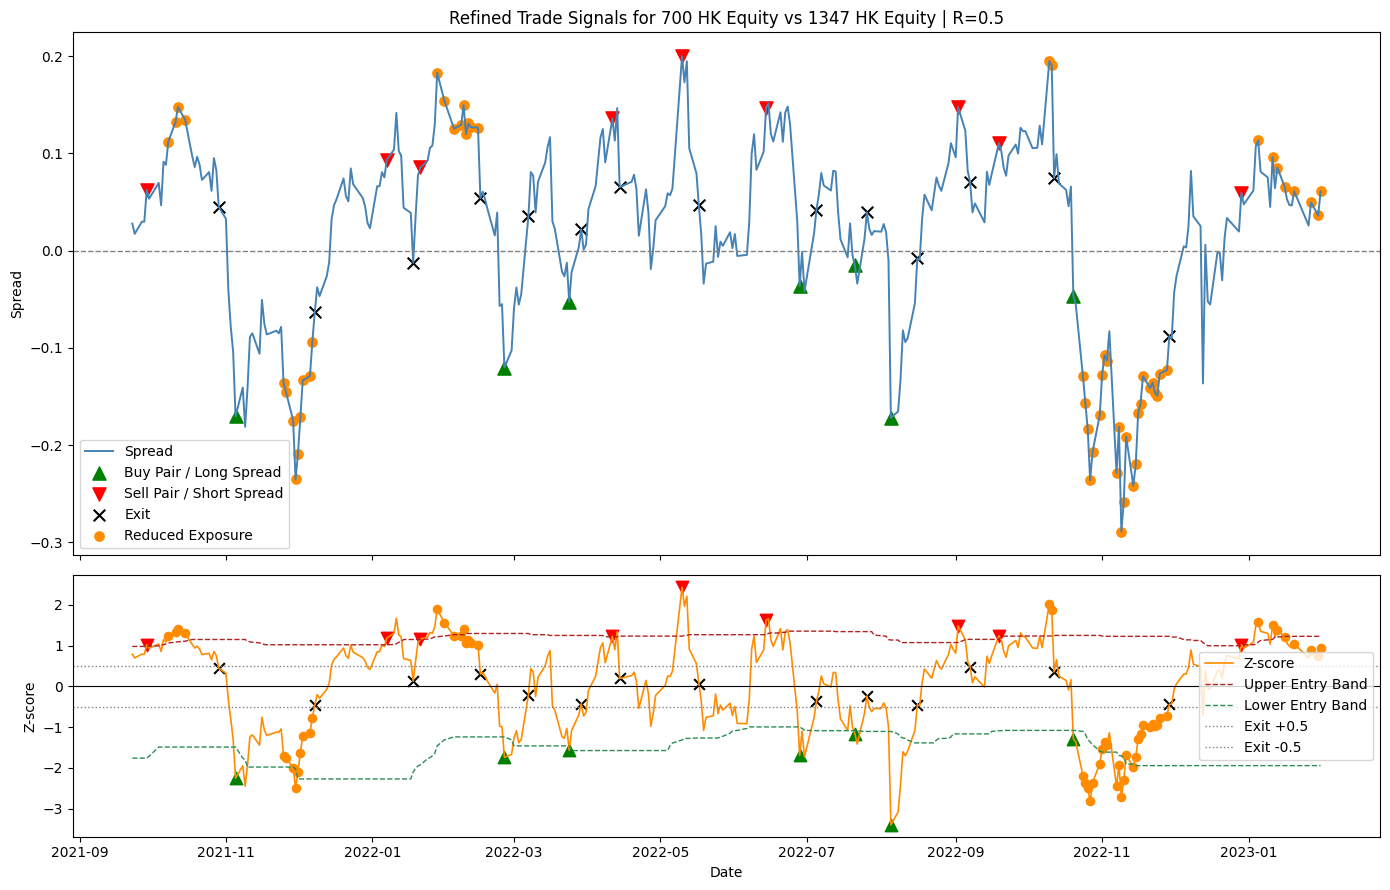

In [18]:
plt.ion()
plot_refined_trade_signals(oos_refined_results, "700 HK Equity vs 1347 HK Equity")

In [19]:
save_dir = "/Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/refined_trading_signal_plots_oos"
os.makedirs(save_dir, exist_ok=True)

plt.ioff()  

pair_r_combinations = (
    oos_refined_results[["pair", "obs_cov"]]
    .drop_duplicates()
    .sort_values(["pair", "obs_cov"])
    .itertuples(index=False, name=None)
)

for pair_name, obs_cov in pair_r_combinations:

    # create the plot
    plot_refined_trade_signals(
        signals_df=oos_refined_results,
        pair_name=pair_name,
        obs_cov=obs_cov
    )

    # clean filename
    clean_pair_name = (
        pair_name
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
    )

    filename = f"refined_{clean_pair_name}_R{obs_cov}.png"
    filepath = os.path.join(save_dir, filename)

    # save current figure
    plt.savefig(filepath, dpi=300, bbox_inches="tight")

    plt.close()

print(f"Saved all refined trade signal plots to: {save_dir}")

Saved all refined trade signal plots to: /Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/refined_trading_signal_plots_oos


### Performance Metrics

In [20]:
rf_oos_fixed = (
    rf_oos
    .copy()
    .reset_index()
    .rename(columns={"date": "Date"})
)

rf_oos_fixed["Date"] = pd.to_datetime(rf_oos_fixed["Date"])

In [21]:
refined_oos_performance_metrics = refined_performance_metrics(
    oos_refined_results,
    rf=rf_oos_fixed
)

refined_oos_performance_metrics

,strategy,pair,obs_cov,entry_z,exit_z,z_window,band_window,upper_quantile,lower_quantile,average_pnl,...,annualised_return (%),annualised_volatility (%),sharpe,annualised_sharpe,hit_rate (%),num_trades,max_trade_drawdown,n_obs,n_active_days,active_day_ratio (%)
0,refined_dynamic_bands,1088 HK Equity vs 1171 HK Equity,0.5,NaN,0.5,60,120,0.9,0.1,0.001415,...,33.893383,15.747628,0.135581,2.152285,30.421687,14.50,-0.066482,332,185,55.722892
1,refined_dynamic_bands,1088 HK Equity vs 1171 HK Equity,1.0,NaN,0.5,60,120,0.9,0.1,0.001398,...,33.489700,15.721053,0.134193,2.130245,31.325301,15.00,-0.074331,332,189,56.927711
2,refined_dynamic_bands,1088 HK Equity vs 1171 HK Equity,5.0,NaN,0.5,60,120,0.9,0.1,-0.000144,...,-5.390991,15.023955,-0.022604,-0.358826,27.710843,9.50,-0.092472,332,181,54.518072
3,refined_dynamic_bands,1088 HK Equity vs 3993 HK Equity,0.5,NaN,0.5,60,120,0.9,0.1,0.001517,...,36.465804,20.277907,0.113282,1.798302,25.903614,16.00,-0.105010,332,149,44.879518
4,refined_dynamic_bands,1088 HK Equity vs 3993 HK Equity,1.0,NaN,0.5,60,120,0.9,0.1,0.000788,...,18.097475,21.419425,0.053224,0.844909,29.518072,13.00,-0.133453,332,179,53.915663
5,refined_dynamic_bands,1088 HK Equity vs 3993 HK Equity,5.0,NaN,0.5,60,120,0.9,0.1,0.000270,...,5.064083,21.707645,0.014696,0.233286,30.421687,11.50,-0.145761,332,190,57.228916
6,refined_dynamic_bands,1347 HK Equity vs 268 HK Equity,0.5,NaN,0.5,60,120,0.9,0.1,0.002658,...,65.225440,29.335701,0.140062,2.223415,28.012048,17.00,-0.160524,332,160,48.192771
7,refined_dynamic_bands,1347 HK Equity vs 268 HK Equity,1.0,NaN,0.5,60,120,0.9,0.1,0.001923,...,46.700367,30.092109,0.097761,1.551914,28.313253,14.50,-0.178153,332,173,52.108434
8,refined_dynamic_bands,1347 HK Equity vs 268 HK Equity,5.0,NaN,0.5,60,120,0.9,0.1,0.000039,...,-0.766484,24.769078,-0.001949,-0.030945,22.891566,9.50,-0.175801,332,142,42.771084
9,refined_dynamic_bands,1898 HK Equity vs 2386 HK Equity,0.5,NaN,0.5,60,120,0.9,0.1,0.000792,...,18.208350,27.669116,0.041455,0.658075,27.710843,15.25,-0.221553,332,174,52.409639
